In [1]:
# %%
# %%
import os
import sys
import numpy as np
# from torch.utils.data import TensorDataset, DataLoader

## Load model module
sys.path.append('/Users/hgoldwyn/Research/projects/SR_CNN/paper_repo/auxilary_modules') #TODO adjust path
sys.path.append('/projects/ecrpstats/distributional_SRCNN/auxilary_modules')
import data_loading

import matplotlib.pyplot as plt

import pandas as pd


train_or_load = 'load'
# %%
hr_data_size = 64
lr_data_size = 8
# %%
epochs = 300
batch_size = 32
##
num_sing_mode = 50
##
region = 0
subregion = 'all'

log_file_base_path = 'parCov_fitting'

save_path = f'{log_file_base_path}.pt'

## ~~~~~~~~~~~
## import data
xtrainHR, xtestHR, xtrainLR, xtestLR = data_loading.import_data(
    region,
    subregion,
    train_fraction=.75, 
    order='(subregion, time)'
    )

failed to find data in /projects/...: [Errno 2] No such file or directory: '/projects/ecrpstats/distributional_SRCNN/data/subregions_wind_u_64x64.npy'


In [2]:
xtrainHR.shape

(642, 1, 64, 64)

In [3]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [4]:
targets = xtestHR.squeeze()

Define basis functions

In [5]:
N = 64
def compl_dft_basis(x, y, k_x, k_y):
    return np.exp(1j * 2*np.pi * (k_x*x + k_y*y)/N)

In [6]:
x = np.arange(0, N)

xg = np.tile(x, N)            # generates x-coordinates for the entire grid N*K 
yg = np.repeat(x, N, axis=0)

mat_xg = xg.reshape((64, 64))
mat_yg = yg.reshape((64, 64))

In [7]:
## Create basis functions to max period
# max_T = 20
# min_k = int(N/max_T)
min_k = 0
print(f"min k : {min_k}")
# max_k = (N)//2
max_k = (N)//2 + 1
print(f"max k : {max_k}")

basis_function_k_idx = []
basis_functions = []
for _kx in range(min_k, max_k):
    for _ky in range(min_k, max_k):
        basis_functions.append(
            compl_dft_basis(
                mat_xg, 
                mat_yg, 
                _kx, 
                _ky
                )
            )
        basis_function_k_idx.append((_kx, _ky))
        
basis_functions = np.asarray(basis_functions).reshape((-1, 64**2)).T / N
basis_functions.shape

min k : 0
max k : 33


(4096, 1089)

Functions for sample gen

In [8]:
def get_noise_from_cov_params_fft(cov_params, n_samples=10, N=64):
    """
    Generate spatial noise realizations from Fourier-diagonal covariance.

    Parameters
    ----------
    cov_params : array, shape (1089,) or (33,33)
        Fourier power spectrum (rfft2 layout).
    n_samples : int
        Number of noise realizations.
    N : int
        Grid size (NxN).

    Returns
    -------
    noise : ndarray, shape (n_samples, N*N)
        Spatial noise samples.
    Zk : ndarray, shape (n_samples, 33, 33)
        Standard normal Fourier coefficients (complex).
    """

    # reshape to rfft2 half-plane
    s_k = cov_params.reshape(33, 33)

    # draw complex Gaussian Fourier coefficients
    Zr = np.random.randn(n_samples, 33, 33)
    Zi = np.random.randn(n_samples, 33, 33)
    Zk = (Zr + 1j * Zi) / np.sqrt(2.0)

    # scale by sqrt spectrum
    Fk = Zk * np.sqrt(s_k)[None, :, :]

    # inverse FFT to real space
    noise = np.fft.irfft2(Fk, s=(N, N), norm="ortho")

    return noise.reshape(n_samples, N * N)#, Zk

In [14]:
## analytic results with correct downscaling
p0p5_cov_params = np.load(
    f"../cov_prediction/test_predicted_s.npy"
    )

p0p5_err = np.load(
    "../stage_3/output_data/fcov_GL_mseStart_gPAStdOn0p7_errFields.npy")

In [15]:
# test_p5p5_cov_params = p5p5_cov_params[-214:]
# test_p5p5_cov_params.shape

In [16]:
p0p5_pred = p0p5_err + targets

In [17]:
p0p5_pred.shape

(214, 64, 64)

# Load data

In [18]:
path_to_global_err_fields = "../stage_3/output_data/fcov_GL_mseStart_global_errFields.npy"
global_err_fields = np.load(path_to_global_err_fields)
global_err_fields.shape

(214, 64, 64)

In [19]:
## analytic results with correct downscaling
global_cov_params = np.load("../stage_2/output_2a/anal_sln_global_params.npy")

In [20]:
# global_u, global_s = compute_sigma_svd(global_cov_params)

In [21]:
global_pred = global_err_fields + targets


In [22]:
from skfda import FDataGrid


In [23]:
from skfda.exploratory.depth import ModifiedBandDepth

# Create the depth object
depth = ModifiedBandDepth()

In [24]:
targets.shape

(214, 64, 64)

In [25]:

def global_samples_for_plot(noise, img_idx):
    _img_samples = noise + global_pred[img_idx].ravel()[None, :]
    _out = _img_samples.reshape((-1, hr_data_size, hr_data_size))
    return _out

In [27]:
global_50_coverage = []
p4p5_50_coverage = []

# path_to_img_spec_noise = "/Users/hgoldwyn/Research/projects/SR_CNN/paper_repo/sr_ordered_train0p75/sample_generation/img_spec_noise_compute/kestrel_output/"

for i in range(targets.shape[0]):
    if i % 25 == 0:
        print(i)

    #### Get GLOBAL result
    ## resample noise
    g_noise = get_noise_from_cov_params_fft(global_cov_params, n_samples=100, N=64)
    
    g_samples = g_noise + global_pred[i].ravel()[None, :]

    
    ## Compute surfaces
    fd = FDataGrid(g_samples.reshape((-1, hr_data_size, hr_data_size)))
    # Evaluate depths on the dataset
    depths = depth(fd)
    # Get index of the deepest (median) surface
    median_idx = np.argmax(depths)
    median_surface = fd[median_idx].data_matrix.squeeze()

    # Get central region (e.g., 50% deepest)
    n = len(fd)
    central_region_indices = np.argsort(-depths)[:n // 2]
    central_region = fd[central_region_indices]
    surfaces = central_region.data_matrix
    lower_surface = np.min(surfaces, axis=0)  # shape: (nx, ny)
    upper_surface = np.max(surfaces, axis=0)

    global_50_coverage.append(np.logical_and(
        lower_surface.squeeze() < targets[i],
        upper_surface.squeeze() > targets[i]).sum() / hr_data_size**2
        )
    
    ## Get IMG-SPE result
    # is_noise = np.load(path_to_img_spec_noise + f"p4p5_img_{642+i}_noise_samples.npy") 
    is_samples = (
        p0p5_pred[i].ravel()[None, :] 
        + 
        get_noise_from_cov_params_fft(p0p5_cov_params[i], n_samples=100, N=64) ## is_noise
        # g_noise  ## Use global noise
        )
    
    fd = FDataGrid(is_samples.reshape((-1, hr_data_size, hr_data_size)))

    # Evaluate depths on the dataset
    depths = depth(fd)
    # Get index of the deepest (median) surface
    median_idx = np.argmax(depths)
    median_surface = fd[median_idx].data_matrix.squeeze()

    # Get central region (e.g., 50% deepest)
    n = len(fd)
    central_region_indices = np.argsort(-depths)[:n // 2]
    central_region = fd[central_region_indices]
    surfaces = central_region.data_matrix
    lower_surface = np.min(surfaces, axis=0)  # shape: (nx, ny)
    upper_surface = np.max(surfaces, axis=0)

    p4p5_50_coverage.append(np.logical_and(
        lower_surface.squeeze() < targets[i],
        upper_surface.squeeze() > targets[i]).sum() / hr_data_size**2
        )
    
    # if i == 10:
    #     break


0
25
50
75
100
125
150
175
200


In [28]:
global_50_coverage = np.asarray(global_50_coverage)
p0p5_50_coverage = np.asarray(p4p5_50_coverage)

In [29]:
np.save('global_coverage_50per.npy', global_50_coverage)
np.save('p0p5_coverage_50per.npy', p0p5_50_coverage)

In [ ]:
# global_50_coverage =  np.load('global_coverage_50per.npy')
# p0p5_50_coverage =  np.load('p0p5_coverage_50per.npy')

(0.4, 1.03)

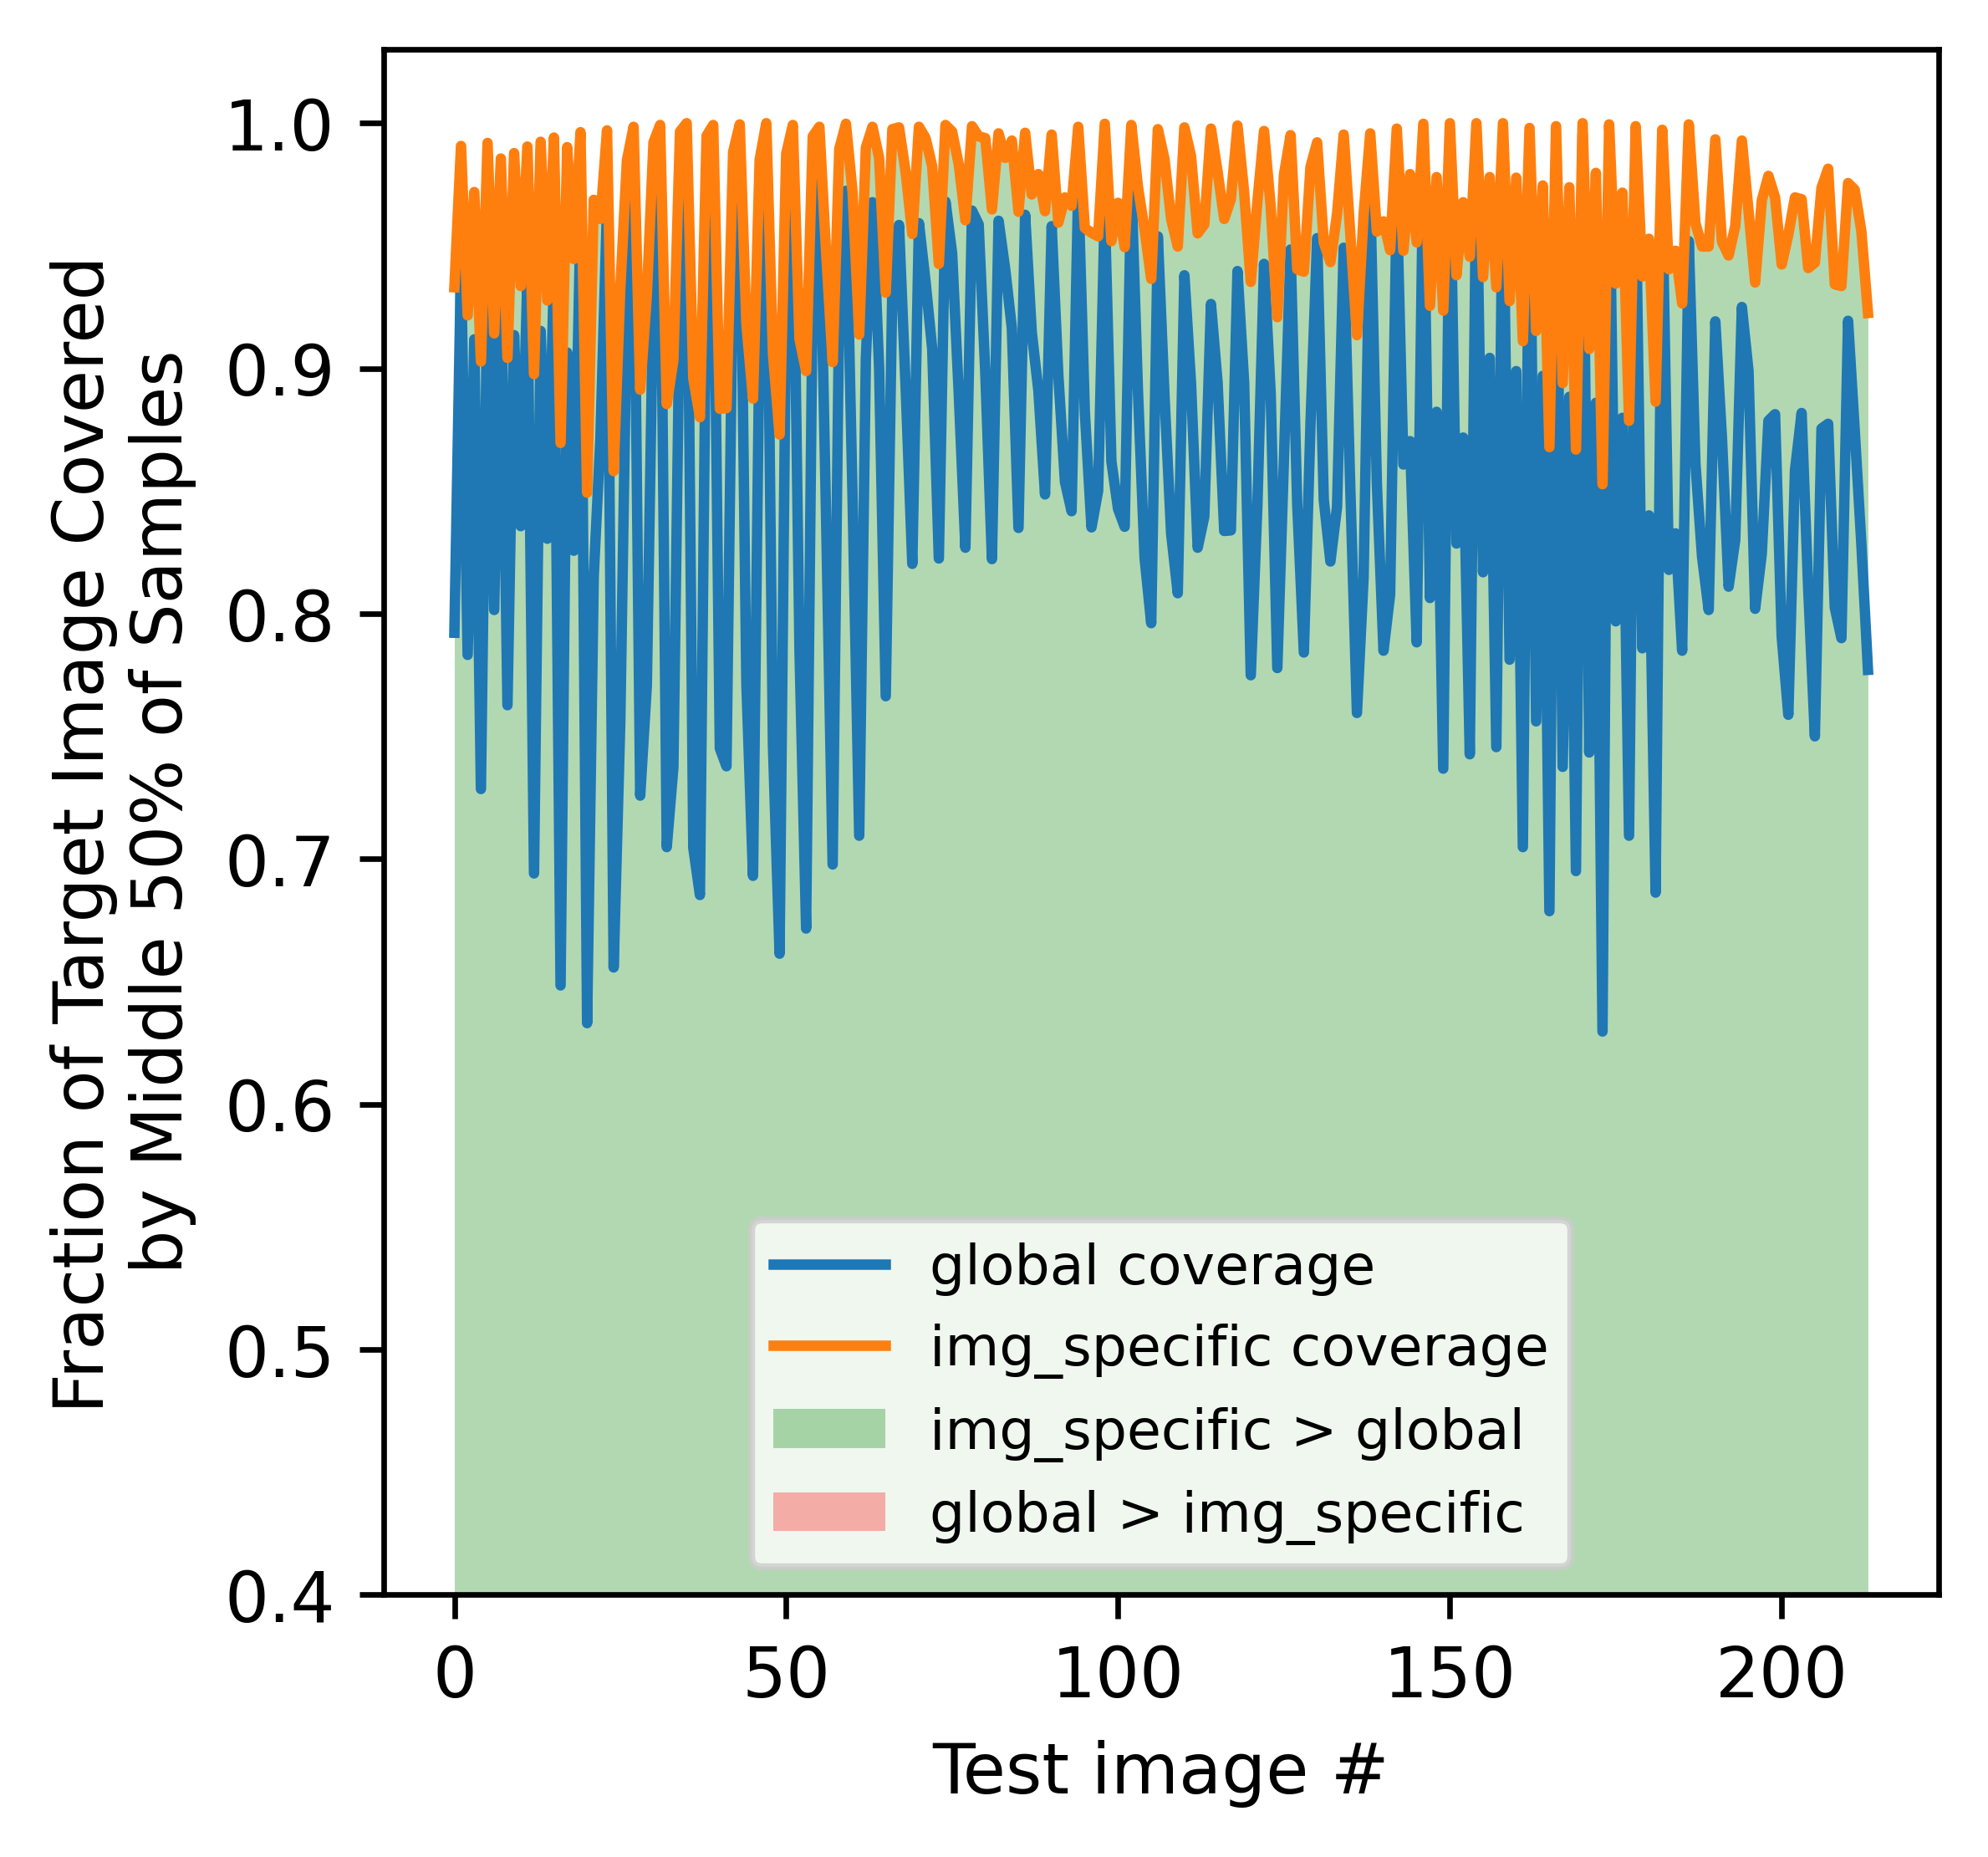

In [ ]:
x = np.arange(len(global_50_coverage))  # or your actual x-axis values

plt.figure(figsize=(4, 4), dpi=600)

# Plot the curves
plt.plot(x, global_50_coverage, label='global coverage', color='C0')
plt.plot(x, p0p5_50_coverage, label='img_specific coverage', color='C1')

plt.fill_between(
    x,
    0.4,
    p0p5_50_coverage,
    where=(p0p5_50_coverage > global_50_coverage),
    # interpolate=True,
    linewidth=0,
    color='green',
    alpha=0.3,
    label='img_specific > global'
)

# Fill red where p0p5_50_coverage < global_50_coverage
plt.fill_between(
    x,
    0.4,
    p0p5_50_coverage,
    where=(p0p5_50_coverage <= global_50_coverage),
    # interpolate=True,
    linewidth=0,
    color='red',
    alpha=0.3,
    label='global > img_specific'
)

plt.xlabel('Test image #')
plt.ylabel('Fraction of Target Image Covered \n by Middle 50% of Samples')

plt.legend(loc='lower center', fontsize=8)
plt.ylim((0.4, plt.gca().get_ylim()[1]))

In [ ]:
# Pad array if length is not divisible by 4
remainder = len(global_50_coverage) % 4
if remainder != 0:
    padding = 4 - remainder
    global_50_coverage = np.pad(global_50_coverage, (0, padding), constant_values=np.nan)  # or choose a padding method

# Reshape and reorder
reshaped = global_50_coverage.reshape(-1, 4)  # shape: (N, 4)
reordered_global_50_coverage = reshaped.T.flatten()  # take columns in order

# Optionally remove padding
reordered_global_50_coverage = reordered_global_50_coverage[~np.isnan(reordered_global_50_coverage)]  # only if you padded with NaNs

In [ ]:
# Pad array if length is not divisible by 4
remainder = len(p0p5_50_coverage) % 4
if remainder != 0:
    padding = 4 - remainder
    p0p5_50_coverage = np.pad(p0p5_50_coverage, (0, padding), constant_values=np.nan)  # or choose a padding method

# Reshape and reorder
reshaped = p0p5_50_coverage.reshape(-1, 4)  # shape: (N, 4)
reordered_p0p5_50_coverage = reshaped.T.flatten()  # take columns in order

# Optionally remove padding
reordered_p0p5_50_coverage = reordered_p0p5_50_coverage[~np.isnan(reordered_p0p5_50_coverage)]  # only if you padded with NaNs

(0.4, 1.03)

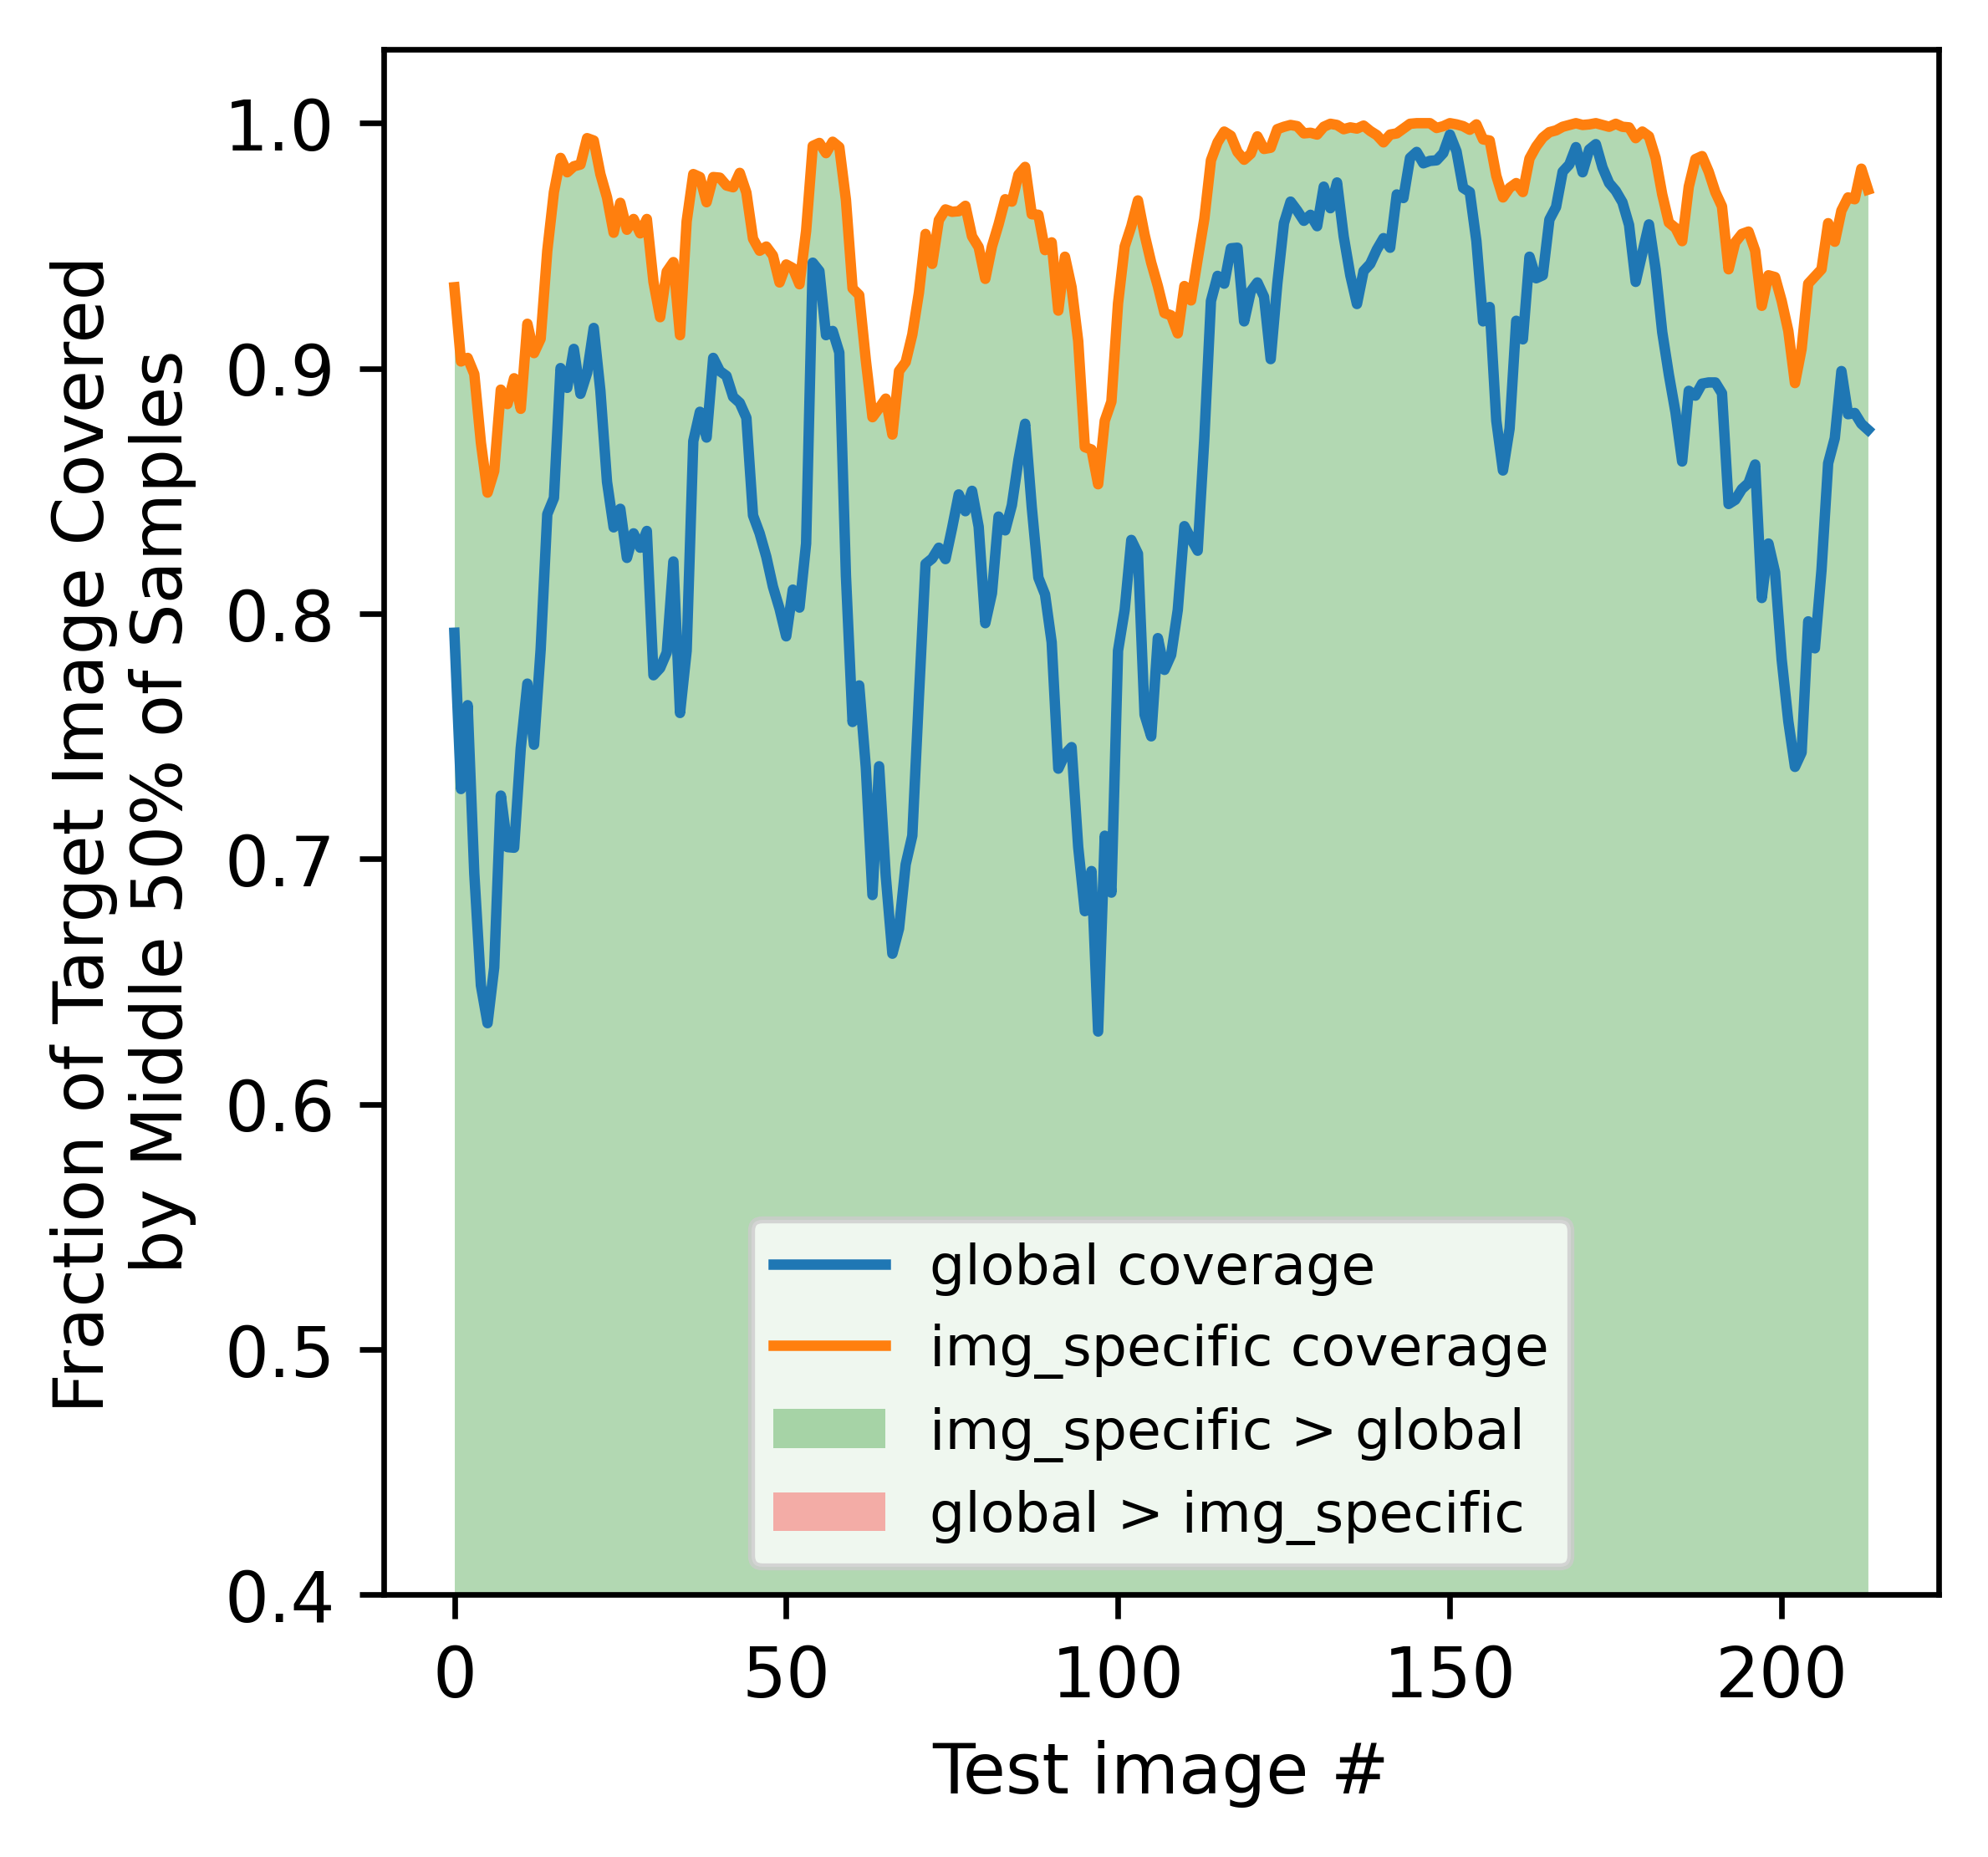

In [ ]:
x = np.arange(len(reordered_global_50_coverage))  # or your actual x-axis values

plt.figure(figsize=(4, 4), dpi=600)

# Plot the curves
plt.plot(x, reordered_global_50_coverage, label='global coverage', color='C0')
plt.plot(x, reordered_p0p5_50_coverage, label='img_specific coverage', color='C1')

plt.fill_between(
    x,
    0.4,
    reordered_p0p5_50_coverage,
    where=(reordered_p0p5_50_coverage > reordered_global_50_coverage),
    # interpolate=True,
    linewidth=0,
    color='green',
    alpha=0.3,
    label='img_specific > global'
)

# Fill red where reordered_p0p5_50_coverage < reordered_global_50_coverage
plt.fill_between(
    x,
    0.4,
    reordered_p0p5_50_coverage,
    where=(reordered_p0p5_50_coverage <= reordered_global_50_coverage),
    # interpolate=True,
    linewidth=0,
    color='red',
    alpha=0.3,
    label='global > img_specific'
)

plt.xlabel('Test image #')
plt.ylabel('Fraction of Target Image Covered \n by Middle 50% of Samples')

plt.legend(loc='lower center', fontsize=8)
plt.ylim((0.4, plt.gca().get_ylim()[1]))

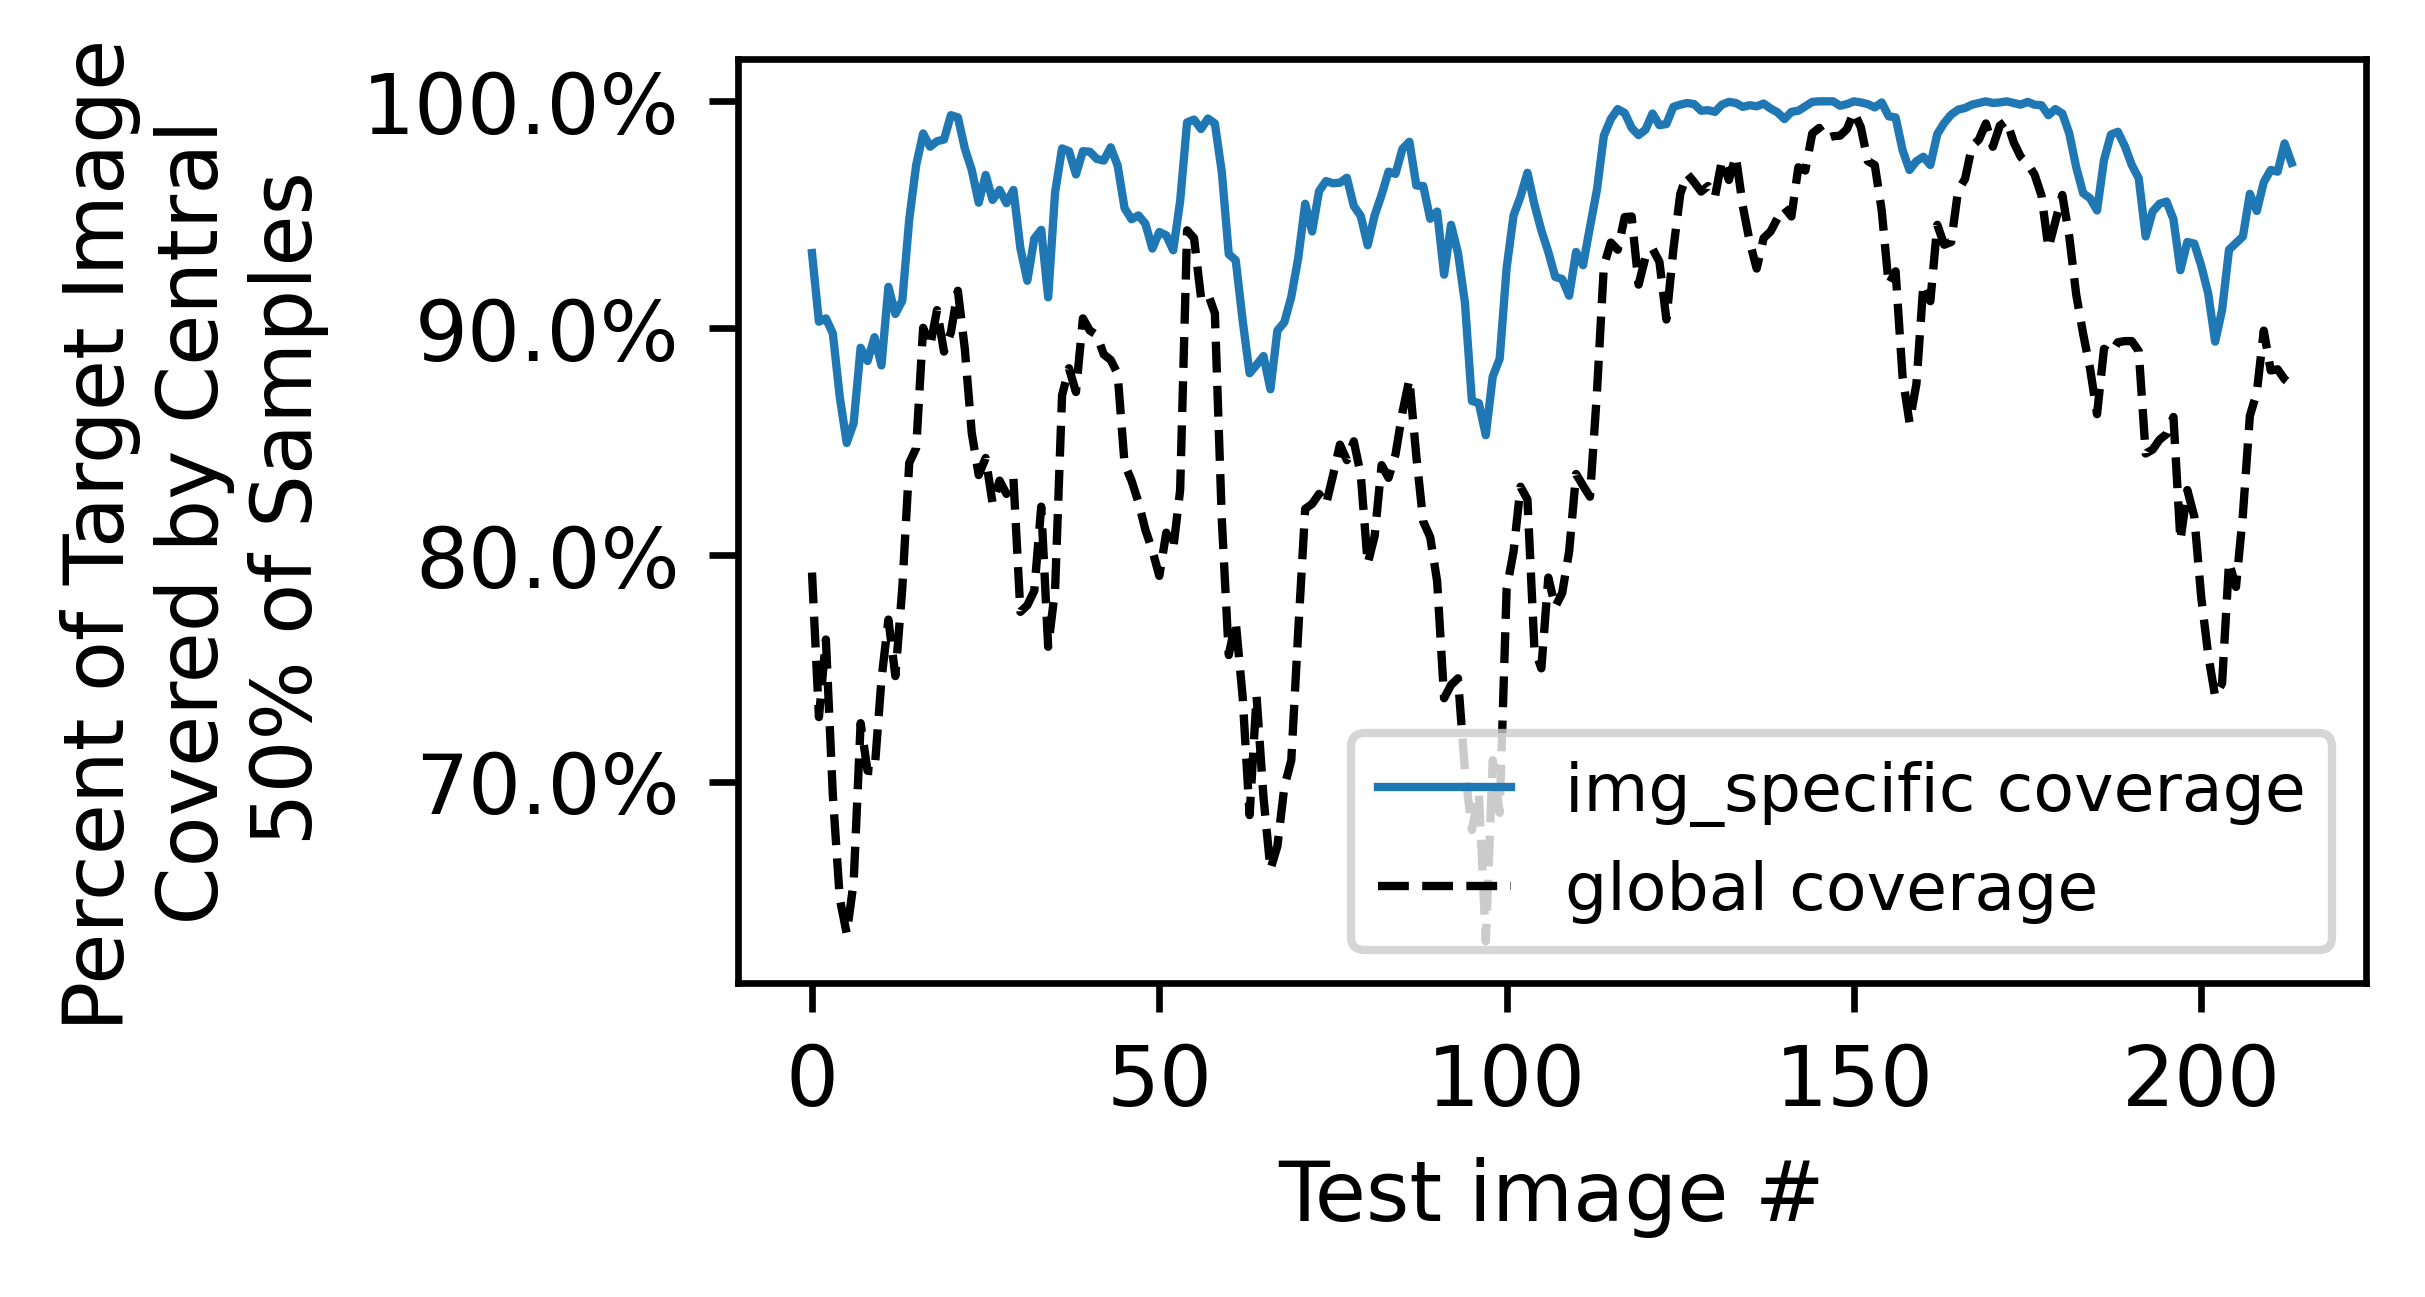

In [ ]:
from matplotlib.ticker import PercentFormatter

x = np.arange(len(reordered_global_50_coverage))  # or your actual x-axis values

plt.figure(figsize=(3.5, 2), dpi=600)

# Plot the curves
plt.plot(x, reordered_p0p5_50_coverage, label='img_specific coverage', color='C0',
         ls='-', 
         lw=1,
        #  marker='.',
         )
plt.plot(x, reordered_global_50_coverage, label='global coverage', 
         ls='--', 
         lw=1,
        #  marker='.',
         color='k')


plt.xlabel('Test image #')
plt.ylabel('Percent of Target Image \n Covered by Central \n 50% of Samples')

plt.legend(
    # loc='lower center', 
    fontsize=8
    )


plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))  # xmax=1 assumes y-values in [0, 1]


In [39]:
reordered_p0p5_50_coverage.shape

(214,)

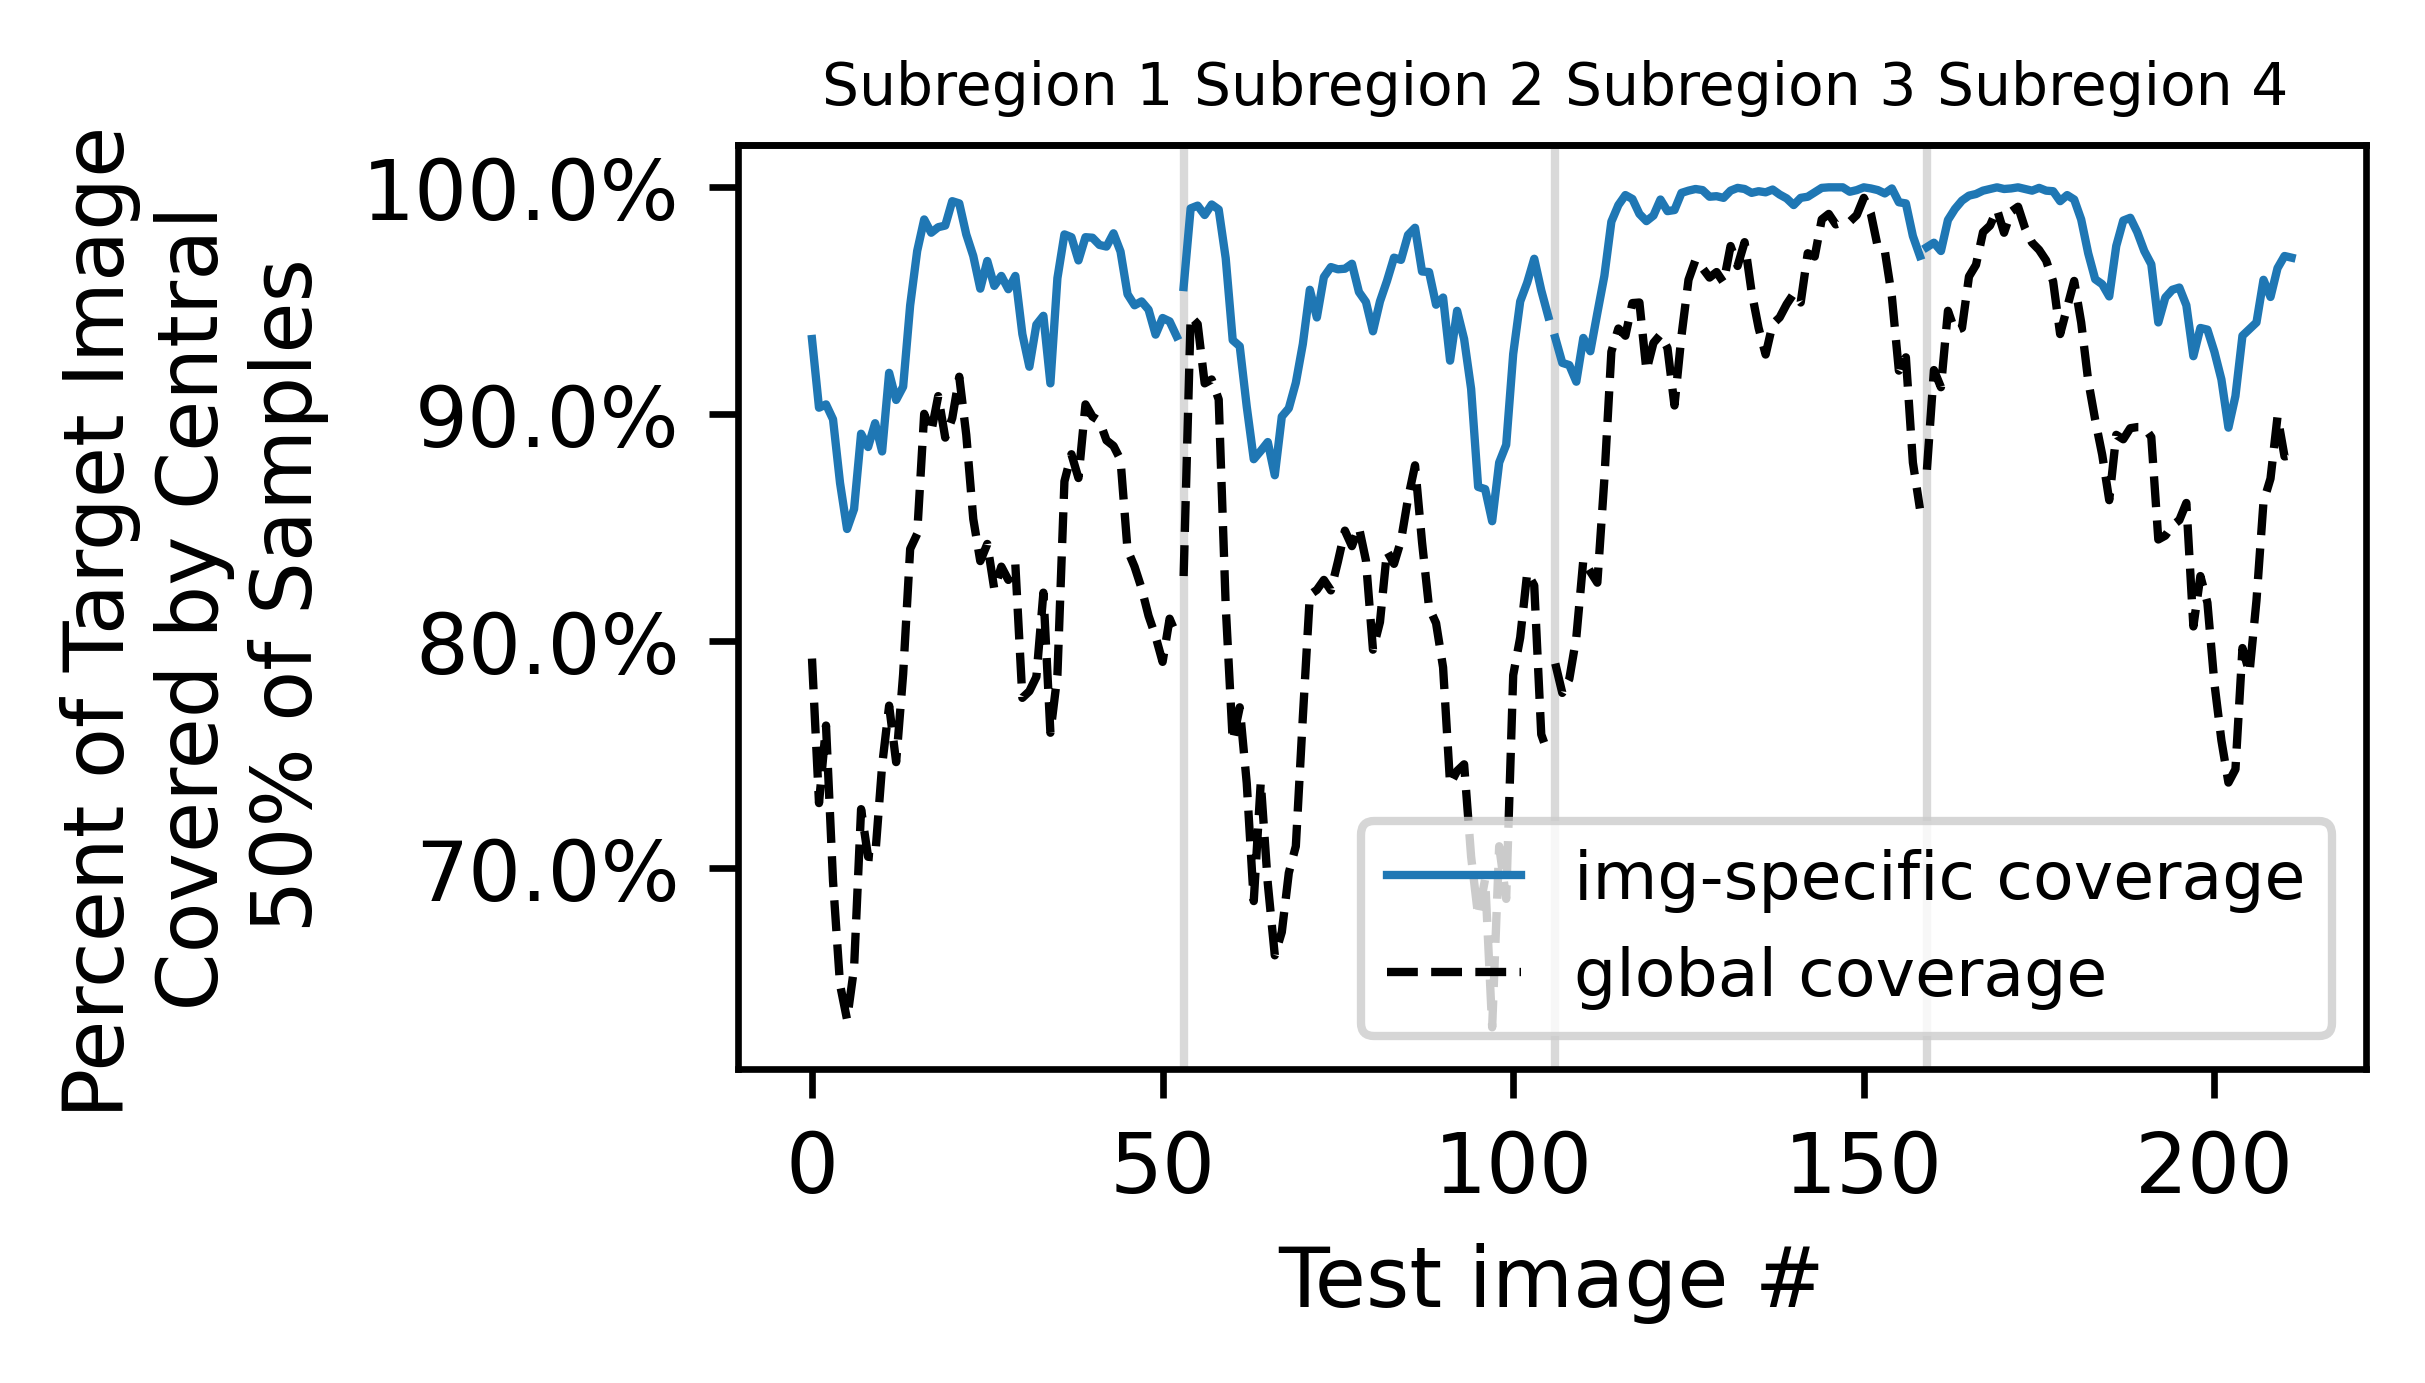

In [60]:
from matplotlib.ticker import PercentFormatter
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(reordered_global_50_coverage))
N = len(x)
n_regions = 4
region_size = N // n_regions

fig, ax = plt.subplots(figsize=(3.5, 2), dpi=600)

# -------------------------------------------------
# Plot each subregion separately (no cross-region lines)
# -------------------------------------------------
for i in range(n_regions):
    i0 = i * region_size
    i1 = (i + 1) * region_size

    ax.plot(
        x[i0:i1],
        reordered_p0p5_50_coverage[i0:i1],
        color='C0',
        lw=1,
        label='img-specific coverage' if i == 0 else None
    )

    ax.plot(
        x[i0:i1],
        reordered_global_50_coverage[i0:i1],
        color='k',
        ls='--',
        lw=1,
        label='global coverage' if i == 0 else None
    )

# -------------------------------------------------
# Axis labels and formatting
# -------------------------------------------------
ax.set_xlabel('Test image #')
ax.set_ylabel('Percent of Target Image \n Covered by Central \n 50% of Samples')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

ax.legend(fontsize=8)

# -------------------------------------------------
# Secondary x-axis indicating subregions (no title)
# -------------------------------------------------
ax_top = ax.secondary_xaxis('top')

region_centers = [
    region_size * (i + 0.5) for i in range(n_regions)
]

ax_top.set_xticks(region_centers)
ax_top.set_xticklabels(
    [f'Subregion {i+1}' for i in range(n_regions)],
    fontsize=7
)
ax_top.tick_params(axis='x', length=0)


# -------------------------------------------------
# Optional subtle separators (recommended)
# -------------------------------------------------
for i in range(1, n_regions):
    ax.axvline(
        i * region_size,
        color='0.85',
        lw=1.0,
        zorder=0
    )

# plt.tight_layout()
# plt.show()


Mean wind field

In [31]:
mean_test_field = xtestHR.mean(axis=(0, 1))

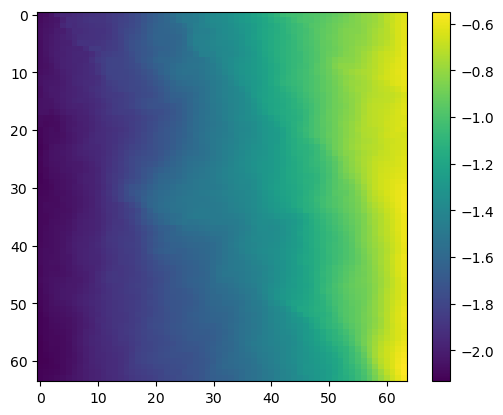

In [33]:
plt.imshow(mean_test_field)
plt.colorbar()

Can I reorder to get mean wind field per subregion?

In [87]:
sr_test_mean = []
for sr_idx in range(4):
    _, xtestHR, _, _ = data_loading.import_data(
        region,
        sr_idx,
        train_fraction=.75, 
        order='(subregion, time)'
        )
    sr_test_mean.append(xtestHR[:, 0].mean(axis=0))

failed to find data in /projects/...: [Errno 2] No such file or directory: '/projects/ecrpstats/distributional_SRCNN/data/subregions_wind_u_64x64.npy'
failed to find data in /projects/...: [Errno 2] No such file or directory: '/projects/ecrpstats/distributional_SRCNN/data/subregions_wind_u_64x64.npy'
failed to find data in /projects/...: [Errno 2] No such file or directory: '/projects/ecrpstats/distributional_SRCNN/data/subregions_wind_u_64x64.npy'
failed to find data in /projects/...: [Errno 2] No such file or directory: '/projects/ecrpstats/distributional_SRCNN/data/subregions_wind_u_64x64.npy'


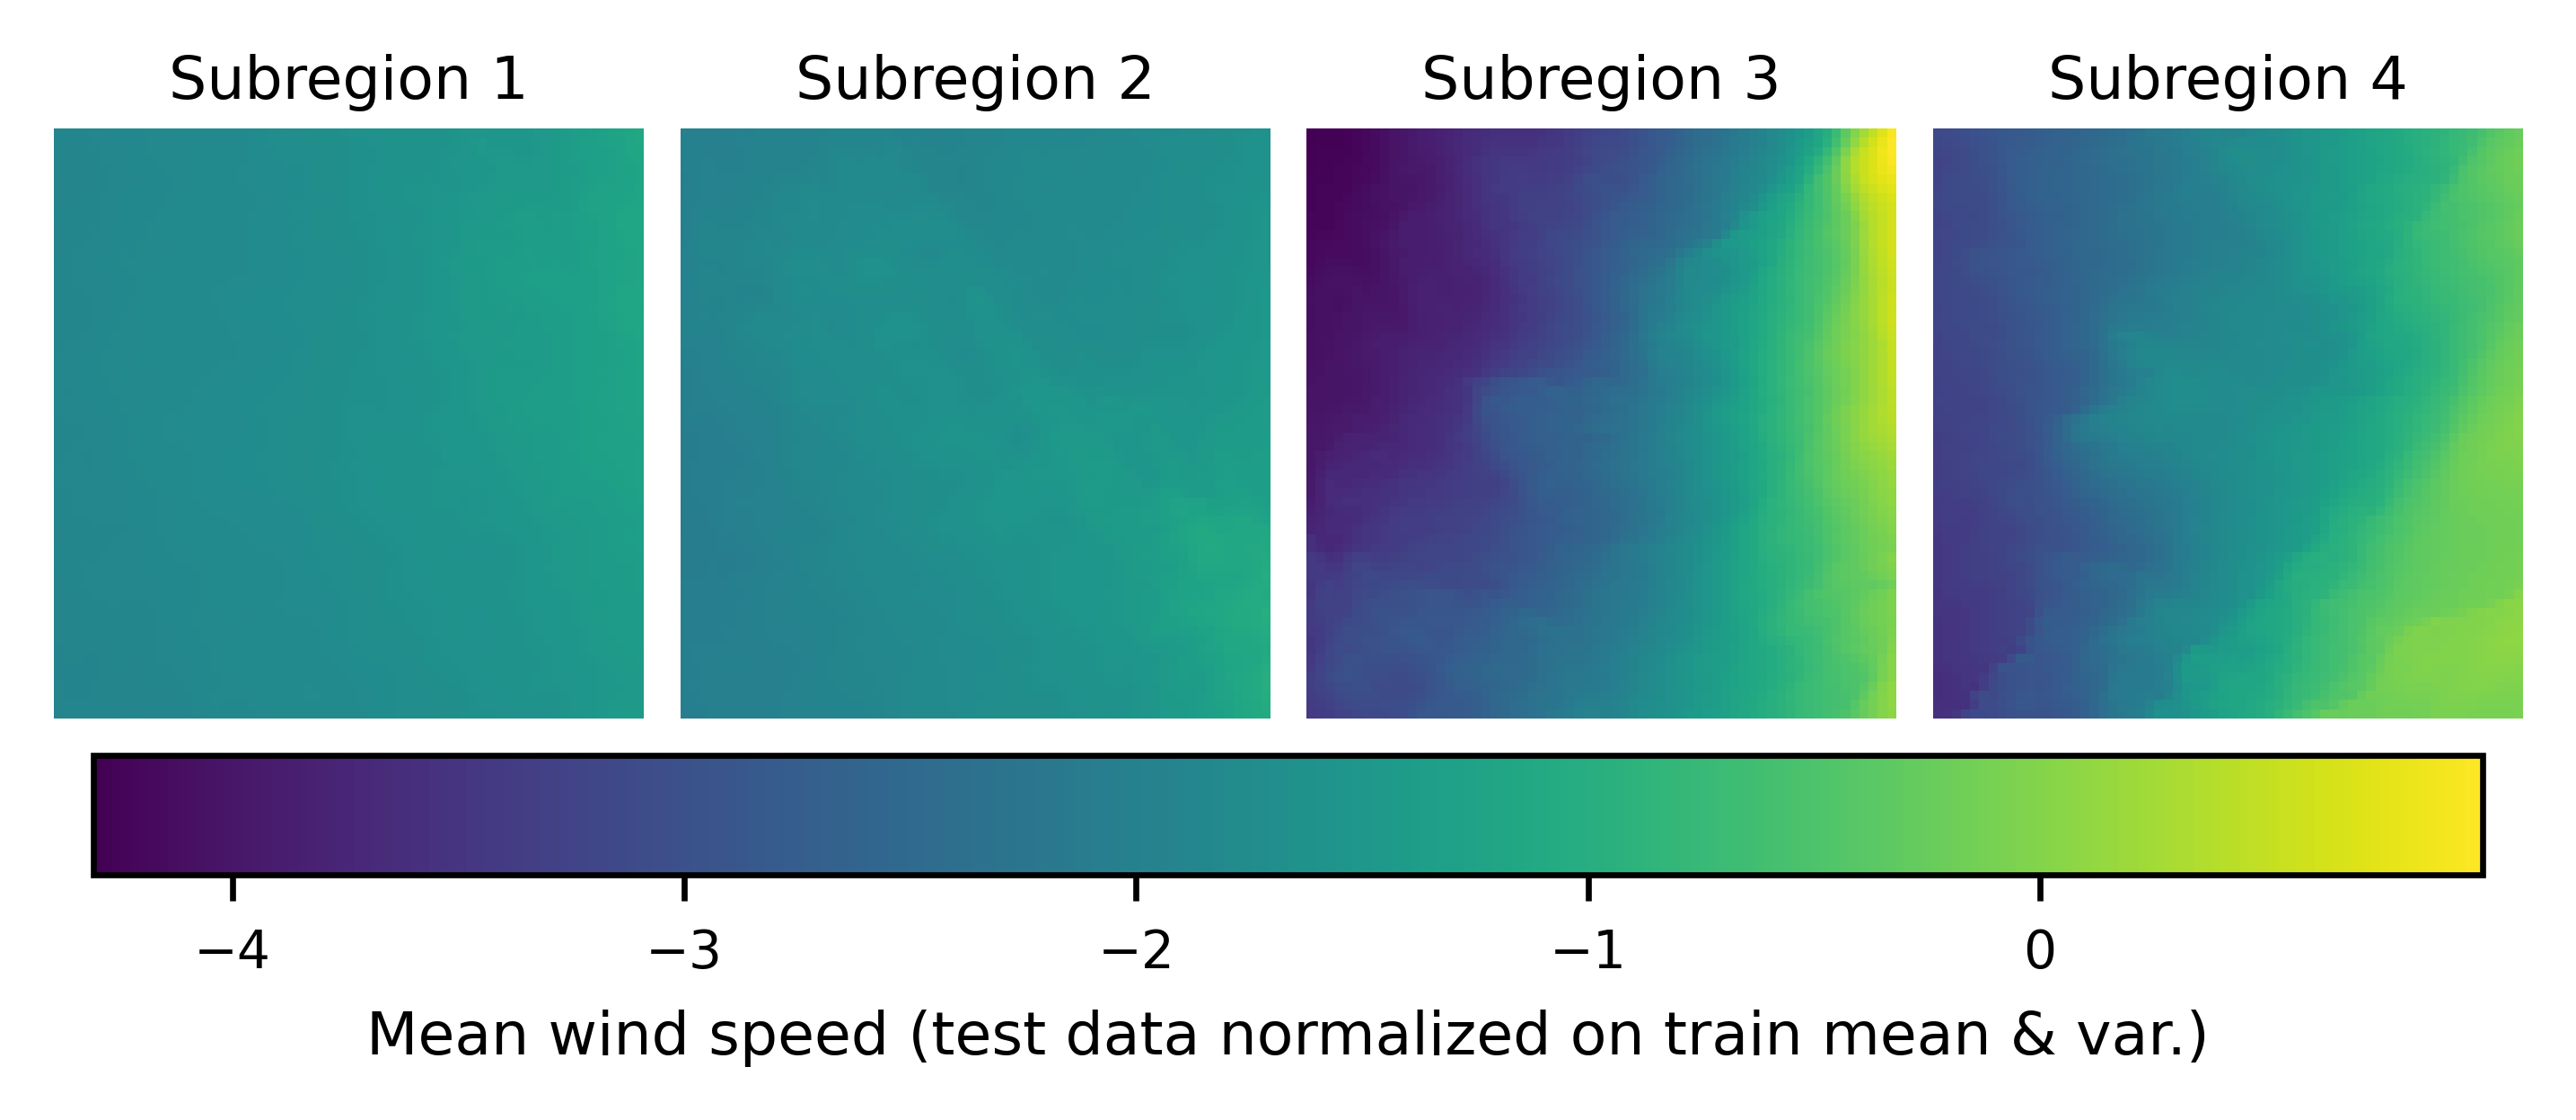

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# sr_test_mean should be a list of 4 arrays, each (H, W)
# built as you showed in your loop

fig, axs = plt.subplots(
    1, 4,
    figsize=(7.0, 1.8),   # tuned for single-column + readability
    dpi=600,
    gridspec_kw=dict(wspace=-0.4)
)

# Shared color limits
vmin = min(m.min() for m in sr_test_mean)
vmax = max(m.max() for m in sr_test_mean)

# Plot
for i, ax in enumerate(axs):
    im = ax.imshow(
        sr_test_mean[i],
        origin='lower',
        vmin=vmin,
        vmax=vmax,
        cmap='viridis'
    )
    ax.set_title(f'Subregion {i+1}', fontsize=8, pad=4)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axs,
    orientation='horizontal',
    fraction=0.16,
    pad=0.05
)
cbar.set_label('Mean wind speed (test data normalized on train mean & var.)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.show()


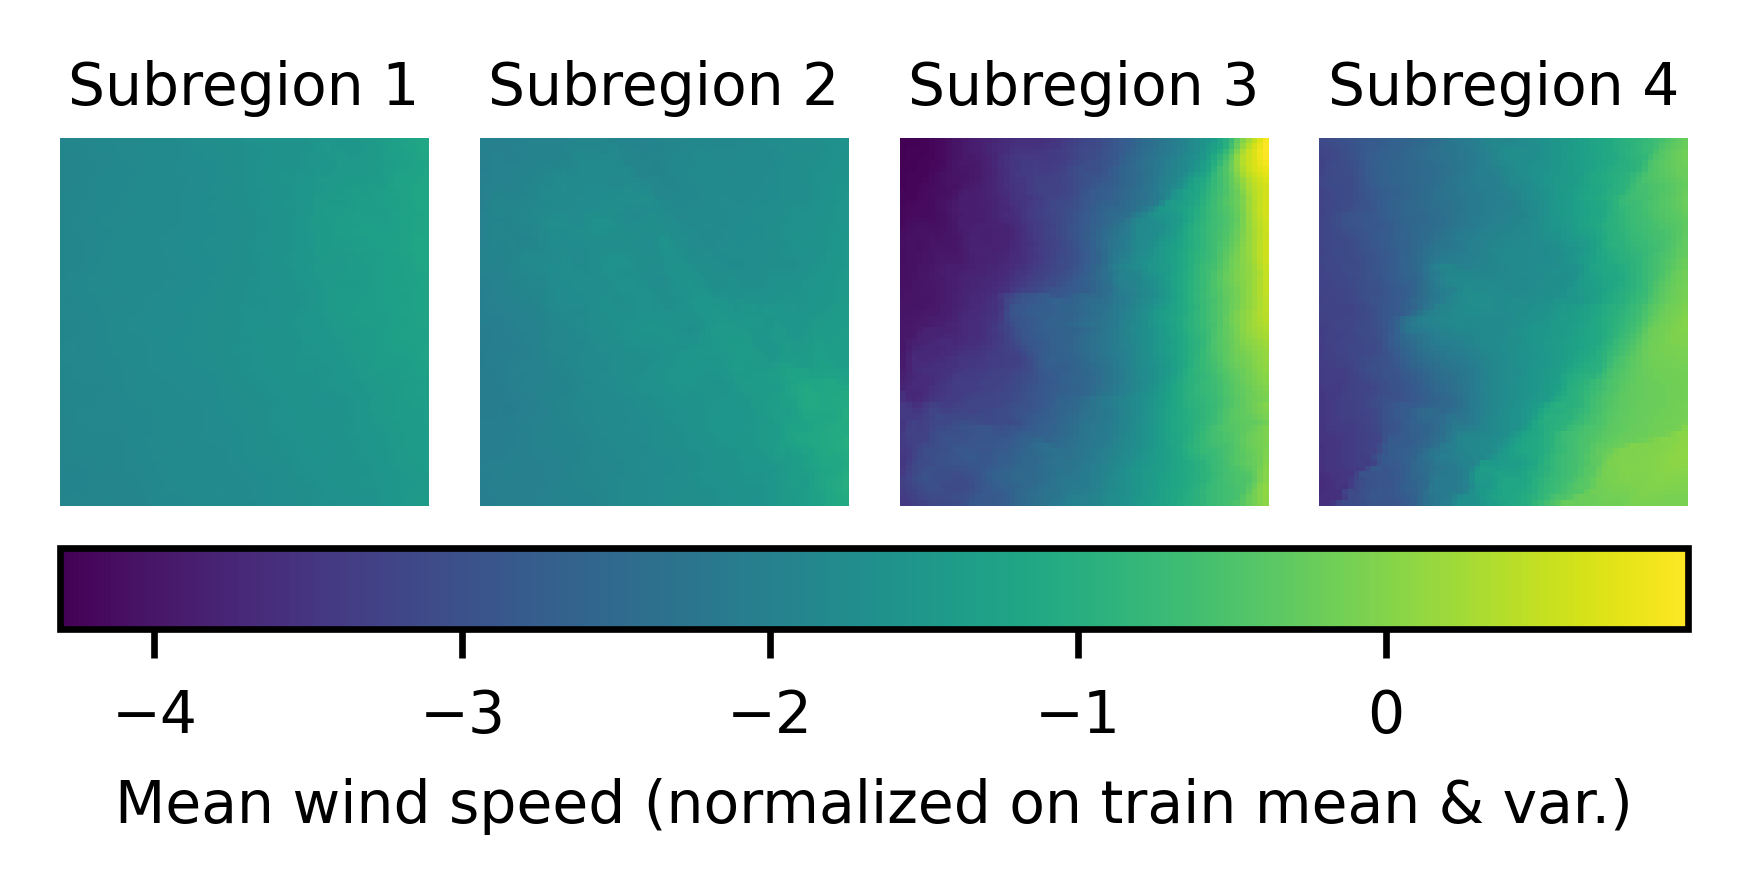

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# sr_test_mean should be a list of 4 arrays, each (H, W)
# built as you showed in your loop

fig, axs = plt.subplots(
    1, 4,
    figsize=(3.5, 1.8),   # tuned for single-column + readability
    dpi=600,
    gridspec_kw=dict(wspace=0.14)
)

# Shared color limits
vmin = min(m.min() for m in sr_test_mean)
vmax = max(m.max() for m in sr_test_mean)

# Plot
for i, ax in enumerate(axs):
    im = ax.imshow(
        sr_test_mean[i],
        origin='lower',
        vmin=vmin,
        vmax=vmax,
        cmap='viridis'
    )
    ax.set_title(f'Subregion {i+1}', fontsize=7, pad=4)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axs,
    orientation='horizontal',
    fraction=0.16,
    pad=0.05
)
cbar.set_label('Mean wind speed (normalized on train mean & var.)', fontsize=7)
cbar.ax.tick_params(labelsize=7)

plt.show()
